In [ ]:
#==============  dataset module  ================== 
from sklearn.datasets import load_breast_cancer ,fetch_california_housing
#load-> loads datasets from sklearn's system provived , fetch -> pull datasets from internet, make-> randomly generate datasets 

In [2]:
df=load_breast_cancer(as_frame=True).frame
df2=fetch_california_housing(as_frame=True).frame

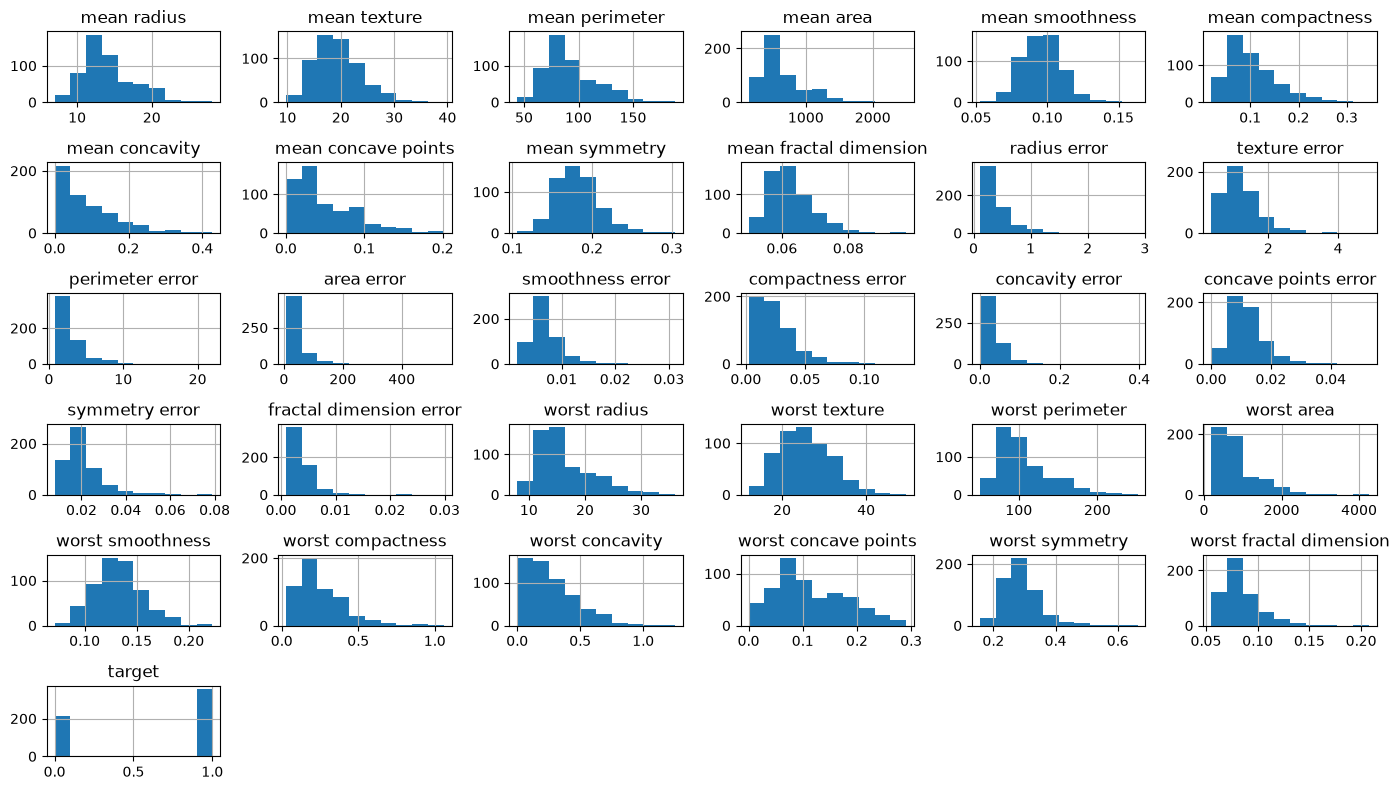

In [6]:
import matplotlib.pyplot as plt 
df.hist(figsize=(14,8))
plt.tight_layout()


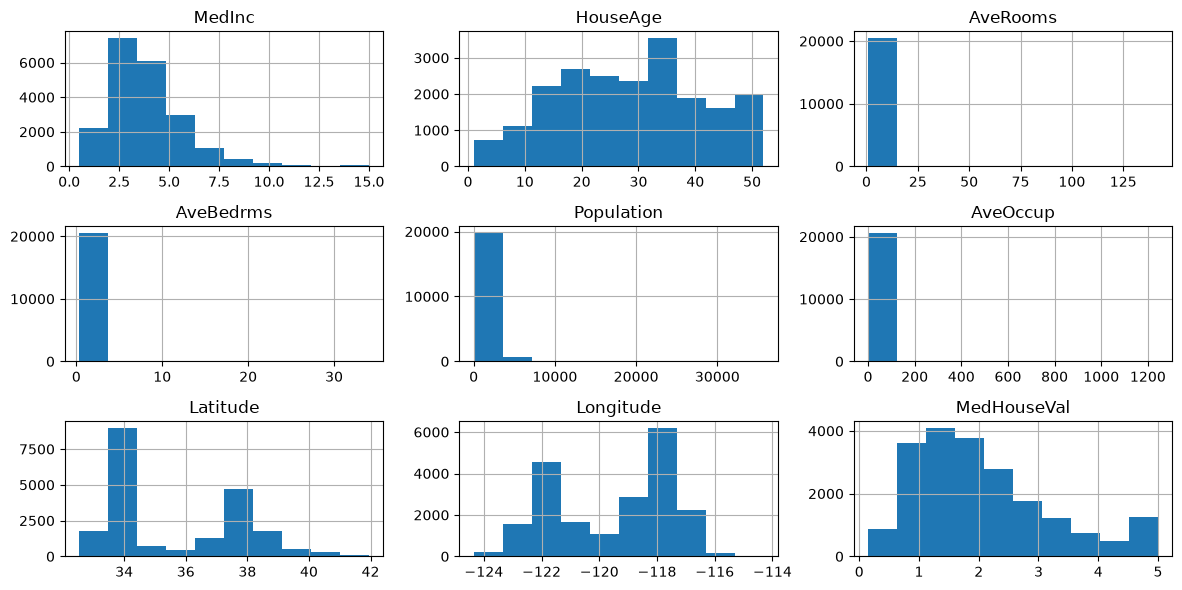

In [9]:
df2.hist(figsize=(12,6))
plt.tight_layout()

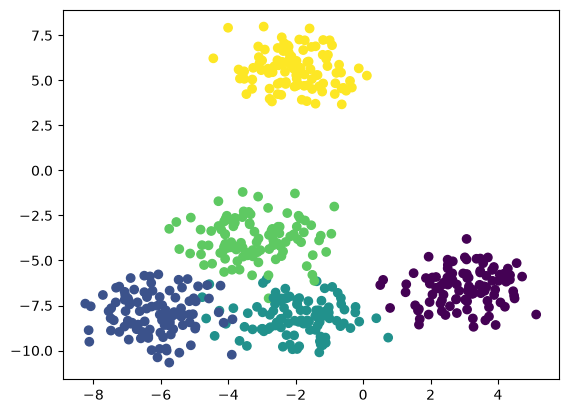

In [ ]:
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
X,y=make_blobs(n_samples=500,centers=5)
plt.scatter(X[:,0],X[:,1],c=y)

In [ ]:
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt 
x,y=make_blobs(n_samples=1000,centers=6,n_features=4)# default n_features=2
x

array([[ -4.75075911,  -5.71517523,  -7.68670867,  -4.68203366],
       [  2.41171009,   6.62430688,   2.4396449 ,   3.07747473],
       [ -9.33411859,   1.08780838,   7.93564836,  -5.75524819],
       ...,
       [ -0.89412423,   9.37348635, -10.29776901,  -9.37456482],
       [  0.43725013,   7.00082478,   2.96200895,   2.75151256],
       [ -8.59302341,  -0.27271252,   9.64158726,  -6.11027318]],
      shape=(1000, 4))

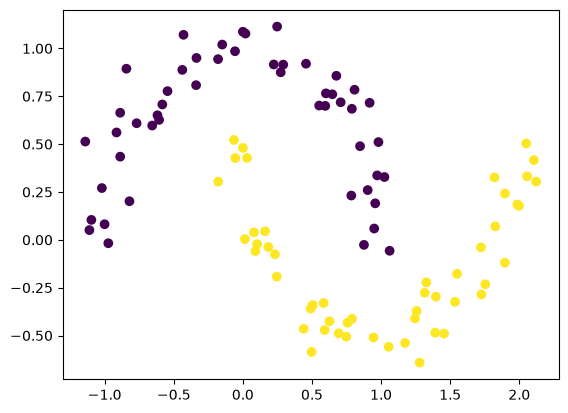

In [ ]:
from sklearn.datasets import make_moons
x2,y2=make_moons(noise=0.1,random_state=2)  #random state => seeds which produces always same output , noise => randomness
plt.scatter(x2[:,0],x2[:,1],c=y2)

In [11]:
#================  splitting data (model selection ) ================
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
df=load_iris()
x,y=df['data'],df['target'] 

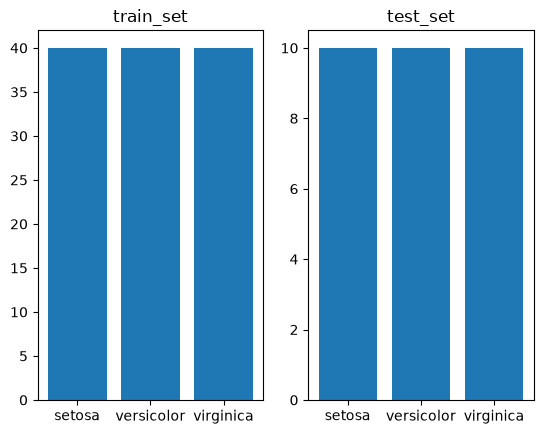

In [12]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,stratify=y) 
#stratification helps to select equal no. of train set  of each groups or class (like three groups or species of iris flower in this case)
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
fig,axes=plt.subplots(1,2)
axes[0].bar(df['target_names'],pd.Series(y_train).value_counts())
axes[0].set_title('train_set')
axes[1].bar(df['target_names'],np.bincount(y_test))  #np.bincount is pplicable to non negative values only 
axes[1].set_title('test_set')
plt.show()

In [ ]:
# using dedicated stratifiedshufflesplit 
from sklearn.model_selection import StratifiedShuffleSplit
split=StratifiedShuffleSplit(n_splits=1,test_size=0.2)
for train_idx,test_idx in split.split(x,y):
    x_train,x_test=x[train_idx],x[test_idx]
    y_train,y_test=y[train_idx],y[test_idx]


120

<BarContainer object of 3 artists>

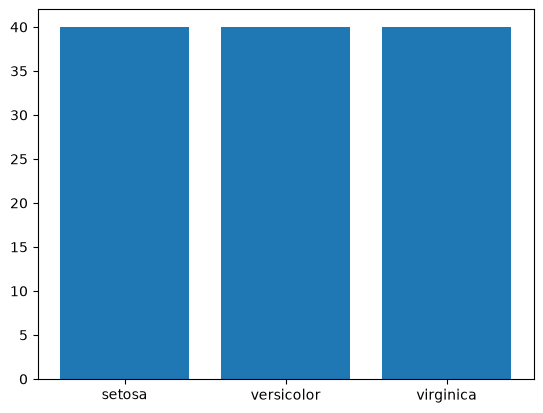

In [ ]:
import matplotlib.pyplot as plt 
import numpy as np 
plt.bar(df['target_names'],np.bincount(y_train))
plt.title()

In [15]:
y_train

array([0, 2, 0, 1, 0, 2, 1, 0, 2, 1, 2, 2, 2, 1, 1, 1, 0, 2, 1, 0, 0, 2,
       1, 0, 0, 0, 2, 2, 1, 2, 0, 1, 1, 0, 1, 0, 1, 2, 1, 2, 1, 0, 2, 0,
       1, 1, 1, 2, 2, 2, 0, 1, 1, 1, 1, 2, 1, 0, 0, 0, 0, 0, 2, 1, 2, 1,
       2, 0, 1, 0, 2, 2, 1, 0, 2, 1, 1, 2, 1, 0, 2, 0, 1, 2, 0, 1, 0, 0,
       2, 1, 0, 0, 2, 2, 0, 1, 1, 2, 0, 0, 1, 2, 0, 0, 2, 2, 1, 0, 1, 0,
       2, 2, 1, 1, 0, 2, 2, 2, 0, 2])

In [1]:
#========  preprocessing ===========
from sklearn.datasets import  load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


In [2]:
x,y=load_iris(return_X_y=True)
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)

In [ ]:
scaler=StandardScaler() 
 # 0. fit calculates mean and std, so it is necessary to run fit at first  
 # 1.does same as transformed_value = z = (x-miu)/sigma by transform function 
 # 2. changes radically different scales in to same scale with mean=0 and sd=1
 # 3. we use mean and std of trainset also in case of test set so only transform is sufficient to call
x_train_scaled=scaler.fit_transform(x_train) #OR,(x_train-np.mean(x_train,axis=0))/np.std(x_train,axis=0)
x_test_scaled=scaler.transform(x_test)


In [14]:
#similar concept as standard scaler but transformed_value = (value-min_value)/(max_value-min_value)
from sklearn.preprocessing import MinMaxScaler
scaler1=MinMaxScaler()
x_train_scaled1=scaler1.fit_transform(x_train)
x_test_scaled1=scaler1.transform(x_test)


In [15]:
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import OrdinalEncoder

In [57]:
data=fetch_openml('car',as_frame=True).frame
data

/home/umesh/.local/lib/python3.14/site-packages/sklearn/datasets/_openml.py:328: UserWarning: Multiple active versions of the dataset matching the name car exist. Versions may be fundamentally different, returning version 2. Available versions:
- version 2, status: active
  url: https://www.openml.org/search?type=data&id=991
- version 3, status: active
  url: https://www.openml.org/search?type=data&id=40975

  warn(warning_msg)


,buying,maint,doors,persons,lug_boot,safety,binaryClass
0,vhigh,vhigh,2,2,small,low,P
1,vhigh,vhigh,2,2,small,med,P
2,vhigh,vhigh,2,2,small,high,P
3,vhigh,vhigh,2,2,med,low,P
4,vhigh,vhigh,2,2,med,med,P
...,...,...,...,...,...,...,...
1723,low,low,5more,more,med,med,N
1724,low,low,5more,more,med,high,N
1725,low,low,5more,more,big,low,P
1726,low,low,5more,more,big,med,N


In [62]:
encoder=OrdinalEncoder(categories=[['small','med','big'],['low','med','high']])
data[['lug_boot','safety']]=encoder.fit_transform(data[['lug_boot','safety']])
data

,buying,maint,doors,persons,lug_boot,safety,binaryClass
0,vhigh,vhigh,2,2,0.0,0.0,P
1,vhigh,vhigh,2,2,0.0,1.0,P
2,vhigh,vhigh,2,2,0.0,2.0,P
3,vhigh,vhigh,2,2,1.0,0.0,P
4,vhigh,vhigh,2,2,1.0,1.0,P
...,...,...,...,...,...,...,...
1723,low,low,5more,more,1.0,1.0,N
1724,low,low,5more,more,1.0,2.0,N
1725,low,low,5more,more,2.0,0.0,P
1726,low,low,5more,more,2.0,1.0,N


In [63]:
data[['lug_boot','safety']]=encoder.inverse_transform(data[['lug_boot','safety']])
data

,buying,maint,doors,persons,lug_boot,safety,binaryClass
0,vhigh,vhigh,2,2,small,low,P
1,vhigh,vhigh,2,2,small,med,P
2,vhigh,vhigh,2,2,small,high,P
3,vhigh,vhigh,2,2,med,low,P
4,vhigh,vhigh,2,2,med,med,P
...,...,...,...,...,...,...,...
1723,low,low,5more,more,med,med,N
1724,low,low,5more,more,med,high,N
1725,low,low,5more,more,big,low,P
1726,low,low,5more,more,big,med,N


In [77]:
data=fetch_openml('adult',as_frame=True).frame
data

/home/umesh/.local/lib/python3.14/site-packages/sklearn/datasets/_openml.py:328: UserWarning: Multiple active versions of the dataset matching the name adult exist. Versions may be fundamentally different, returning version 1. Available versions:
- version 1, status: active
  url: https://www.openml.org/search?type=data&id=179
- version 2, status: active
  url: https://www.openml.org/search?type=data&id=1590

  warn(warning_msg)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capitalgain,capitalloss,hoursperweek,native-country,class
0,2,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,1,0,2,United-States,<=50K
1,3,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,0,United-States,<=50K
2,2,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,2,United-States,<=50K
3,3,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,2,United-States,<=50K
4,1,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,2,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,2,Private,215419,Bachelors,13,Divorced,Prof-specialty,Not-in-family,White,Female,0,0,2,United-States,<=50K
48838,4,NaN,321403,HS-grad,9,Widowed,NaN,Other-relative,Black,Male,0,0,2,United-States,<=50K
48839,2,Private,374983,Bachelors,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,3,United-States,<=50K
48840,2,Private,83891,Bachelors,13,Divorced,Adm-clerical,Own-child,Asian-Pac-Islander,Male,2,0,2,United-States,<=50K


In [89]:
from sklearn.preprocessing import OneHotEncoder
encoder=OneHotEncoder(handle_unknown='ignore',sparse_output=False)
encoded_values=encoder.fit_transform(data[['occupation','race']])   #stored in single variable cause onehotencoder returns single array 
new_cols=encoder.get_feature_names_out(['occupation','race'])

In [92]:
import pandas as pd 
encoded_df=pd.DataFrame(encoded_values,columns=new_cols,index=data.index)
pd.concat([data.drop(columns=['occupation','race']),encoded_df],axis=1)

,age,workclass,fnlwgt,education,education-num,marital-status,relationship,sex,capitalgain,capitalloss,...,occupation_Protective-serv,occupation_Sales,occupation_Tech-support,occupation_Transport-moving,occupation_nan,race_Amer-Indian-Eskimo,race_Asian-Pac-Islander,race_Black,race_Other,race_White
0,2,State-gov,77516,Bachelors,13,Never-married,Not-in-family,Male,1,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,3,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Husband,Male,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,2,Private,215646,HS-grad,9,Divorced,Not-in-family,Male,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,3,Private,234721,11th,7,Married-civ-spouse,Husband,Male,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,1,Private,338409,Bachelors,13,Married-civ-spouse,Wife,Female,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,2,Private,215419,Bachelors,13,Divorced,Not-in-family,Female,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
48838,4,NaN,321403,HS-grad,9,Widowed,Other-relative,Male,0,0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
48839,2,Private,374983,Bachelors,13,Married-civ-spouse,Husband,Male,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
48840,2,Private,83891,Bachelors,13,Divorced,Own-child,Male,2,0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [ ]:
#========  target: descrete value -> classifer  ========
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier 
# OR(same) from sklearn.linear_model import LogisticRegression  
#from sklearn.tree import DecisionTreeClassifier
#from sklearn.svm import SVC -> supports predit_proba()  only if initialized with true ie. clf=SVC(probability=True)
#from sklearn.ensemble import RandomForestClassifier -> RandomeForestClassifier(n_estimators= <no. of decision tree we want > )
#from sklearn.naive_bayes import GaussinNB  -> fastest model but with lower accuracy compared to others and doesn't support predit_proba()

#all are nearly same but recommended : LogisticRegrssion and RandomForestClassifier


In [4]:
x,y=load_breast_cancer(return_X_y=True)
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)


In [5]:
clf=KNeighborsClassifier() # OR. KNeighborClassifier(n_neightbors= <no. of neighbors to look at>) 
clf.fit(x_train_scaled,y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [6]:
clf.score(x_test_scaled,y_test)

0.9649122807017544

In [11]:
single_instance=x_test_scaled[8]
clf.predict([single_instance])


array([1])

In [12]:
y_test[8]

np.int64(1)

In [13]:
clf.predict_proba([single_instance])# output [probability of 0, probability of 1]

array([[0., 1.]])

In [ ]:
#================ target:continous value -> Regressor =============
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

x,y=fetch_california_housing(return_X_y=True)
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [ ]:
#from sklearn.linear_model import LinearRegression # no recommended cuase it's weaak on prediction 
#from skleran.linear_model import Laso,Ridge,ElasticNet -> all separate 
#from sklearn.svm import SVR
#from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor  #->r2=0.80,-> strong
from sklearn.xgboost import XGBRegressor # strongest 
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
reg=XGBRegressor(device='cuda')
reg.fit(x_train_scaled,y_train)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",'cuda'
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [43]:
reg.score(x_test_scaled,y_test) #gives R^2-score(coefficient of determination) not accuracy 

0.8321274129061884

In [44]:
reg.predict([x_test_scaled[0]])

array([3.4739478], dtype=float32)

In [45]:
y_test[0]

np.float64(3.011)